In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ngohoangdang/spam-synthetic-ver-1/spam_synthetic_dataset.json
/kaggle/input/datasets/ngohoangdang/spam-synthetic-ver-1/spam_synthetic_dataset_2.json
/kaggle/input/datasets/ngohoangdang/data-spam-trainning/df_final_1.csv
/kaggle/input/datasets/ngohoangdang/data-spam-trainning/df_train (1).csv
/kaggle/input/datasets/organizations/uciml/sms-spam-collection-dataset/spam.csv
/kaggle/input/models/ngohoangdang/spam-detection/pytorch/default/1/model_mix.pt
/kaggle/input/models/ngohoangdang/spam-detection/pytorch/default/1/model_real_only.pt
/kaggle/input/models/ngohoangdang/spam-detection/pytorch/default/1/vocab.pt
/kaggle/input/models/ngohoangdang/spam-detection/pytorch/default/1/model_robus.pt


In [5]:
df = pd.read_csv(
    '/kaggle/input/datasets/organizations/uciml/sms-spam-collection-dataset/spam.csv',
    encoding='latin-1'
)

In [6]:
pd.set_option('display.max_colwidth', None)

In [3]:
!pip install -q transformers accelerate sentence-transformers rapidfuzz pandas tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 34.3 MB/s eta 0:00:00a 0:00:01


In [5]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

model_name = "Qwen/Qwen2-7B-Instruct"  # hoặc model bạn đang dùng

tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True
)

config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Cancellation requested; stopping current tasks.


KeyboardInterrupt: 

In [ ]:
# ================================
# 📂 LOAD DATA
# ================================
import json
import pandas as pd
from tqdm import tqdm
import re
import unicodedata
from rapidfuzz.fuzz import ratio

path1 = "/kaggle/input/datasets/ngohoangdang/spam-synthetic-ver-1/spam_synthetic_dataset.json"
path2 = "/kaggle/input/datasets/ngohoangdang/spam-synthetic-ver-1/spam_synthetic_dataset_2.json"

with open(path1, "r") as f:
    data1 = json.load(f)

with open(path2, "r") as f:
    data2 = json.load(f)

data = data1 + data2

print("Total original samples:", len(data))


# ================================
# 🧠 STAGE 1 — LEVEL VALIDATION
# ================================
def is_L1(text): return any(c in text for c in "013457")
def is_L2(text): return any(c in text for c in "@$!€")
def is_L3(text): return any(s in text.lower() for s in ["txt","gr8","2","&"])
def is_L4(text): return any(c in text for c in ".-/")
def is_L5(text): return len(text.split()) > 20
def is_L6(text): return any(ord(c) > 127 for c in text)
def is_L7(text): return "3" in text or "k" in text.lower()
def is_L8(text): return bool(re.search(r"\d[- ]\d[- ]\d", text))
def is_L9(text): return any(ord(c) > 10000 for c in text)
def is_L10(text): return "[" in text or "]" in text
def is_L11(text):
    count = sum([
        is_L1(text),
        is_L2(text),
        is_L3(text),
        is_L4(text),
        is_L6(text)
    ])
    return count >= 2

def is_valid_by_level(level, text):
    mapping = {
        "L1": is_L1,
        "L2": is_L2,
        "L3": is_L3,
        "L4": is_L4,
        "L5": is_L5,
        "L6": is_L6,
        "L7": is_L7,
        "L8": is_L8,
        "L9": is_L9,
        "L10": is_L10,
        "L11": is_L11
    }
    return mapping.get(level, lambda x: False)(text)

clean_data = []

for item in tqdm(data):

    original = item["real_message"]
    variants = item.get("synthetic_variants", {})

    for level, obf in variants.items():

        if not obf:
            continue

        clean_data.append({
            "original": original,
            "obfuscated": str(obf).strip(),
            "level": level
        })

print("Stage1 samples:", len(clean_data))



def strong_recover(text):

    # fix kiểu: y o u → you
    text = re.sub(r'(?<=\b\w)\s+(?=\w\b)', '', text)

    tokens = text.split()
    new_tokens = []

    for token in tokens:

        # ❗ giữ nguyên số / phone
        if re.fullmatch(r'[\d\-\+]+', token):
            new_tokens.append(token)
            continue

        # ❗ giữ code kiểu W1J6HL
        if re.fullmatch(r'[a-zA-Z]*\d+[a-zA-Z\d]*', token) and len(token) > 5:
            new_tokens.append(token)
            continue

        t = token.lower()
        t = unicodedata.normalize("NFKD", t)
        t = ''.join(c for c in t if not unicodedata.combining(c))

        mapping = {
            "@":"a",
            "3":"e",
            "0":"o",
            "$":"s"
        }

        for k,v in mapping.items():
            t = t.replace(k,v)

        new_tokens.append(t)

    return " ".join(new_tokens)


# ================================
# ⚖️ RECOVER SCORE
# ================================
def recover_score(original, obf):
    rec = strong_recover(obf)
    return ratio(original, rec) / 100.0

# ================================
# ⚖️ STAGE 2 — SCORING ONLY (KHÔNG FILTER)
# ================================
stage2_records = []

for item in tqdm(clean_data):

    original = item["original"]
    obf = item["obfuscated"]

    rec = strong_recover(obf)
    score = recover_score(original, obf)

    stage2_records.append({
        **item,
        "recovered": rec,
        "recover_score": score
    })

df_stage2 = pd.DataFrame(stage2_records)

print("Stage2 samples:", len(df_stage2))




Total original samples: 747


100%|██████████| 747/747 [00:00<00:00, 144238.33it/s]


Stage1 samples: 8217


100%|██████████| 8217/8217 [00:01<00:00, 7002.75it/s]

Stage2 samples: 8217


In [ ]:
# ================================
# 🎯 SMART SAMPLING (CHO LLM)
# ================================
import numpy as np

bins = np.linspace(0, 1, 6)
df_stage2["bin"] = pd.cut(df_stage2["recover_score"], bins)

samples = []

for b in df_stage2["bin"].dropna().unique():

    subset = df_stage2[df_stage2["bin"] == b]

    if subset.empty:
        continue

    # ưu tiên vùng khó
    if b.left < 0.4:
        n = min(100, len(subset))
    elif b.left < 0.7:
        n = min(50, len(subset))
    else:
        n = min(20, len(subset))

    samples.append(subset.sample(n, random_state=42))

audit_df = pd.concat(samples).reset_index(drop=True)

print("Audit samples:", len(audit_df))

def strong_recover(text):

    # fix kiểu: y o u → you
    text = re.sub(r'(?<=\b\w)\s+(?=\w\b)', '', text)

    tokens = text.split()
    new_tokens = []

    for token in tokens:

        # ❗ giữ nguyên số / phone
        if re.fullmatch(r'[\d\-\+]+', token):
            new_tokens.append(token)
            continue

        # ❗ giữ code kiểu W1J6HL
        if re.fullmatch(r'[a-zA-Z]*\d+[a-zA-Z\d]*', token) and len(token) > 5:
            new_tokens.append(token)
            continue

        t = token.lower()
        t = unicodedata.normalize("NFKD", t)
        t = ''.join(c for c in t if not unicodedata.combining(c))

        mapping = {
            "@":"a",
            "3":"e",
            "0":"o",
            "$":"s"
        }

        for k,v in mapping.items():
            t = t.replace(k,v)

        new_tokens.append(t)

    return " ".join(new_tokens)


# ================================
# 🤖 LLM RECOVER (QWEN 7B VERSION)
# ================================
from rapidfuzz.fuzz import ratio
import re

def llm_recover_qwen7b(text):

    system_instruction = "You are a professional security analyst specializing in de-obfuscating spam and leetspeak messages."
    
    prompt = f"""{system_instruction}

### TASK
Convert the noisy input message into a clean, standard English sentence. 

### DECODING RULES
1. Remove delimiters (e.g., ".", "-", "_", "[ ]") if they separate letters.
2. Replace Leetspeak: 0->o, 1->i, 3->e, 4->a, 5->s, 7->t, 8->b.
3. Replace symbols: @ -> a, $ -> s, £ -> pounds.
4. Expand abbreviations: "txt" -> "text", "2" -> "to", "4" -> "for", "u" -> "you", "msg" -> "message".
5. Keep shortcodes and phone numbers as continuous digits.
6. Just provide the decoded message, NO NEED TO EXPLAIN

### EXAMPLES
Input: "S.I.X chancε5 t0 w!n C$H! Fr-0-m 100"
Output: Six chances to win cash! From 100

Input: "u r g 3 n t ! y 0 u h a v 3"
Output: Urgent! You have

### INPUT
{text}

### OUTPUT:
"""

    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    input_len = inputs.input_ids.shape[1]

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=120,
            temperature=0.1,
            do_sample=True,
            top_p=0.9
        )

    generated = output[0][input_len:]
    result = tokenizer.decode(generated, skip_special_tokens=True).strip()

    # 🔥 clean output
    result = result.split("\n")[0]

    return result


# ================================
# 🔁 APPLY LLM TO AUDIT SET
# ================================
final_records = []

for _, row in tqdm(audit_df.iterrows(), total=len(audit_df)):

    original = row["original"]
    obf = row["obfuscated"]

    # rule-based
    rule_score = row["recover_score"]

    # LLM recover
    llm_rec = llm_recover_qwen7b(obf)

    # similarity với original
    llm_score = ratio(original, llm_rec) / 100.0

    final_records.append({
        "original": original,
        "obfuscated": obf,
        "rule_recovered": row["recovered"],
        "llm_recovered": llm_rec,
        "rule_score": rule_score,
        "llm_recover_score": llm_score,
        "level": row["level"]
    })


# ================================
# 📊 FINAL DATAFRAME
# ================================
df_final = pd.DataFrame(final_records)

print("\nFinal samples:", len(df_final))

df_final.head()

In [9]:
df_stage2.to_csv('df_stage2_out.csv')

In [117]:
df_final.sort_values('llm_recover_score',ascending = True)[0:50]

,original,obfuscated,rule_recovered,llm_recovered,rule_score,llm_recover_score,level
272,FREE for 1st week! No1 Nokia tone 4 ur mob every week just txt NOKIA to 8007 Get txting and tell ur mates www.getzed.co.uk POBox 36504 W45WQ norm150p/tone 16+,"""F-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3-.-3","""f-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e-.-e",333333333333333333333333333333333333333333333333333333333333333333333333333333333333333333333333333333333333333333333333,0.020631,0.007194,L4
248,Urgent! Please call 09061743811 from landline. Your ABTA complimentary 4* Tenerife Holiday or å£5000 cash await collection SAE T&Cs Box 326 CW25WX 150ppm,Vr,vr,Vr,0.012903,0.012903,L11
307,"Sppok up ur mob with a Halloween collection of nokia logo&pic message plus a FREE eerie tone, txt CARD SPOOK to 8007","""5.1.7.0.1.1.0.1.1.0.1.1.0.1.1.0.1.1.0.1.1.0.1.1.0.1.1.0.1.1.0.1.1.0.1.1.0.1.1.0.1.1.0.1.1.0.1.1.0.1.1.0.1.1.0.1.1.0.1.1.0.1.1.0.1.1.0.1.1.0.1.1.0.1.1.0.1.1.0.1.1.0.1.1.0.1.1.0.1.1.0.1.1.0.1.1.0.1.1.0.1.1.0.1.1.0.1.1.0.1.1.0.1.1.0.1.1.0.1.1.0.1.1.0.1.1.0.1.1.0.1.1.0.1.1.0.1.1.0.1.1.0.1.1.0.1.1.0.1.1.0.1.1.0

In [141]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

tokenizer = AutoTokenizer.from_pretrained("roberta-base")
model = AutoModelForSequenceClassification.from_pretrained("roberta-base")

print("OK RUNNING")

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

ImportError: cannot import name 'find_pruneable_heads_and_indices' from 'transformers.pytorch_utils' (/usr/local/lib/python3.12/dist-packages/transformers/pytorch_utils.py)

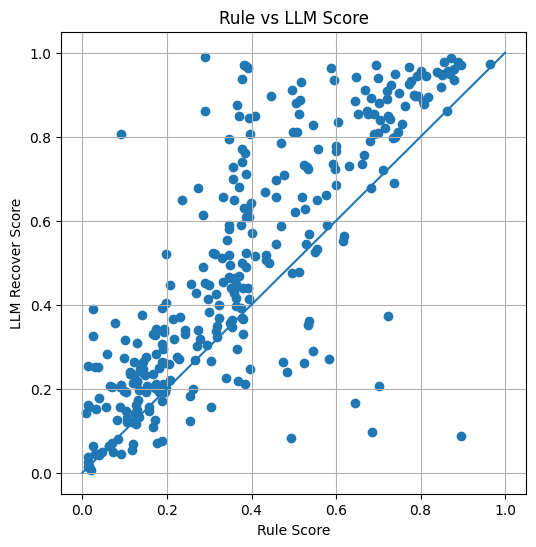

In [118]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(
    df_final["rule_score"],
    df_final["llm_recover_score"]
)

# đường y = x (so sánh)
plt.plot([0,1], [0,1])

plt.xlabel("Rule Score")
plt.ylabel("LLM Recover Score")
plt.title("Rule vs LLM Score")

plt.grid(True)
plt.show()